<a href="https://colab.research.google.com/github/Muen1/har-activity-hmm/blob/main/notebook/HAR_HMM_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Human Activity Recognition with a Hidden Markov Model**

Human Activity Recognition (HAR) is important because it is used to figure out a person’s physical activities without any human assistance. However, HAR faces a major problem which is that smartphones often capture messy data that is inconsistent and requires heavy computers to process. In this project, the goal is to track fitness and activity by using smartphone accelerometer and gyroscope measurements to recognise walking, standing, jumping, and still when there is no movement. I used a Hidden Markov Model because it captures the activity as a sequence of hidden states while accounting for temporal dependencies between consecutive observations, allowing noisy sensor predictions to be smoothed into more consistent activity classifications over time. This temporal modeling makes HMMs well suited for improving the reliability of smartphone-based fitness monitoring systems, where activities naturally occur in continuous sequences rather than as isolated events.

## 0. Setup




In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/HAR_HMM_Data/processed"


Mounted at /content/drive


In [2]:
!pip install hmmlearn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.1 MB/s eta 0:00:00


In [3]:
import glob
import re
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")

logging.getLogger("hmmlearn").setLevel(logging.ERROR)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

ACTIVITIES = ["standing", "walking", "jumping", "still"]
FS = 100


## 1. Load the labelled dataset




In [4]:
files = sorted(glob.glob(f"{DATA_DIR}/*_trial*.csv"))
files = [f for f in files if not Path(f).name.startswith("_")]
print(f"Found {len(files)} trial CSVs")

trials = {}
for f in files:
    df = pd.read_csv(f)
    trials[df["trial_id"].iloc[0]] = df

summary = pd.DataFrame([
    {"trial_id": tid, "activity": df["activity"].iloc[0], "n_samples": len(df),
     "duration_s": round(df["t_seconds"].iloc[-1] - df["t_seconds"].iloc[0], 2)}
    for tid, df in trials.items()
]).sort_values(["activity", "trial_id"]).reset_index(drop=True)
summary


Found 52 trial CSVs


,trial_id,activity,n_samples,duration_s
0,jumping_01,jumping,895,8.91
1,jumping_02,jumping,902,8.98
2,jumping_03,jumping,891,8.86
3,jumping_04,jumping,879,8.75
4,jumping_05,jumping,929,9.24
5,jumping_06,jumping,783,7.79
6,jumping_07,jumping,972,9.67
7,jumping_08,jumping,830,8.26
8,jumping_09,jumping,934,9.29
9,jumping_10,jumping,729,7.25


In [5]:
summary.groupby("activity").agg(
    n_trials=("trial_id", "count"),
    total_duration_s=("duration_s", "sum"),
    mean_duration_s=("duration_s", "mean"),
)


,n_trials,total_duration_s,mean_duration_s
activity,,,
jumping,13,113.80,8.753846
standing,13,106.81,8.216154
still,13,112.61,8.662308
walking,13,118.67,9.128462


## 2. Visualize raw sample data




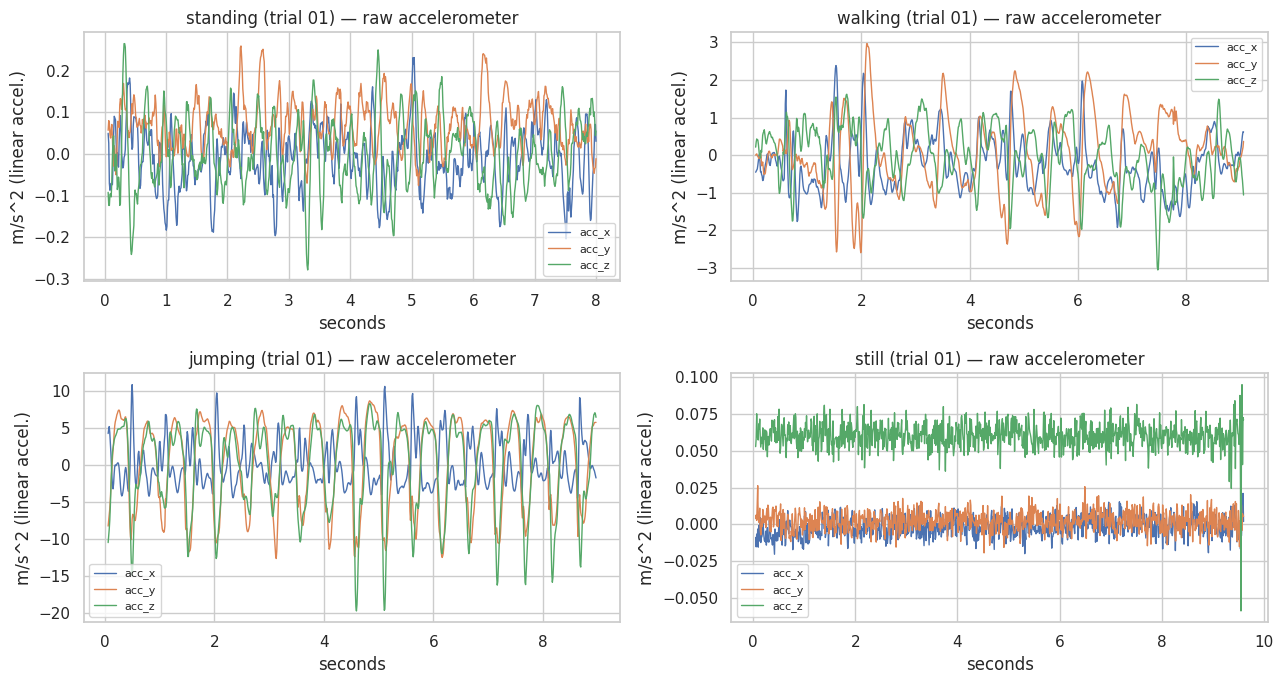

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=False)
example_trials = {act: f"{act}_01" for act in ACTIVITIES}

for ax, act in zip(axes.flat, ACTIVITIES):
    df = trials[example_trials[act]]
    ax.plot(df["t_seconds"], df["acc_x"], label="acc_x", linewidth=1)
    ax.plot(df["t_seconds"], df["acc_y"], label="acc_y", linewidth=1)
    ax.plot(df["t_seconds"], df["acc_z"], label="acc_z", linewidth=1)
    ax.set_title(f"{act} (trial 01) — raw accelerometer")
    ax.set_xlabel("seconds")
    ax.set_ylabel("m/s^2 (linear accel.)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


Jumping and walking show clear periodic oscillation in the accelerometer axes, standing shows small, irregular hand-tremor-scale movement, and still is visibly flat by comparison.

## 3. Windowing strategy



In [9]:
WIN = 100   # 1.0 s at 100 Hz
STEP = 50   # 0.5 s step -> 50% overlap
print(f"Window = {WIN} samples ({WIN/FS:.1f}s), step = {STEP} samples ({STEP/FS:.1f}s)")


Window = 100 samples (1.0s), step = 50 samples (0.5s)


There was a 50% overlap caused by the 100 samples (1.0s) and the step size of 50 samples (0.5s). A 1-second window at 100Hz reliably captures at least one full cycle of movement which is what makes the dominant-frequency and spectral-energy features meaningful. The purpose of the overlap is to allow more training windows per trial for Baum-Welch.


## 4. Feature extraction (time-domain + frequency-domain)




In [10]:
def extract_features(window: pd.DataFrame) -> dict:
    """Computes one feature vector (time + frequency domain) for a single window."""
    feats = {}
    axes = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

    for ax in axes:
        sig = window[ax].values
        feats[f"{ax}_mean"] = np.mean(sig)
        feats[f"{ax}_std"] = np.std(sig)
        feats[f"{ax}_min"] = np.min(sig)
        feats[f"{ax}_max"] = np.max(sig)

        # Frequency domain: FFT of the mean-centered signal
        freqs = rfftfreq(len(sig), d=1.0 / FS)
        mag = np.abs(rfft(sig - np.mean(sig)))
        feats[f"{ax}_domfreq"] = freqs[1:][np.argmax(mag[1:])] if len(mag) > 1 else 0.0
        feats[f"{ax}_specenergy"] = np.sum(mag ** 2) / len(mag)

    # Signal Magnitude Area (mean absolute sum across the three axes)
    feats["acc_sma"] = (window["acc_x"].abs() + window["acc_y"].abs() + window["acc_z"].abs()).sum() / len(window)
    feats["gyro_sma"] = (window["gyro_x"].abs() + window["gyro_y"].abs() + window["gyro_z"].abs()).sum() / len(window)

    # Cross-axis correlation (captures characteristic axis coupling per activity)
    feats["corr_acc_xy"] = np.corrcoef(window["acc_x"], window["acc_y"])[0, 1]
    feats["corr_acc_xz"] = np.corrcoef(window["acc_x"], window["acc_z"])[0, 1]
    feats["corr_acc_yz"] = np.corrcoef(window["acc_y"], window["acc_z"])[0, 1]

    return feats


In [11]:
rows = []
for tid, df in trials.items():
    activity = df["activity"].iloc[0]
    n = len(df)
    start = 0
    while start + WIN <= n:
        feats = extract_features(df.iloc[start:start + WIN])
        feats["activity"] = activity
        feats["trial_id"] = tid
        rows.append(feats)
        start += STEP

feat_df = pd.DataFrame(rows)
feat_df["trial_num"] = feat_df["trial_id"].str.extract(r"_(\d+)$")[0].astype(int)

print(f"Total feature windows: {len(feat_df)}")
feat_df["activity"].value_counts()


Total feature windows: 832


,count
activity,
walking,221
jumping,209
still,206
standing,196


In [12]:
assert feat_df.drop(columns=["activity", "trial_id"]).isna().sum().sum() == 0, "Unexpected NaNs in features"
feature_cols = [c for c in feat_df.columns if c not in ("activity", "trial_id", "trial_num")]
print(f"{len(feature_cols)} features per window")
feat_df.head()


41 features per window


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_domfreq,acc_x_specenergy,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,...,gyro_z_domfreq,gyro_z_specenergy,acc_sma,gyro_sma,corr_acc_xy,corr_acc_xz,corr_acc_yz,activity,trial_id,trial_num
0,-0.237867,2.896721,-4.231166,10.790094,2.0,822.716710,0.670637,5.384329,-10.076250,7.366596,...,5.0,42.031063,11.427237,1.377032,-0.539255,-0.776975,0.924537,jumping,jumping_01,1
1,-0.231221,2.335968,-4.231166,6.761434,2.0,535.020512,-0.037714,5.404968,-11.735150,6.352205,...,2.0,26.692756,10.389885,1.245665,-0.535054,-0.695538,0.935315,jumping,jumping_01,1
2,0.029391,2.927929,-3.925941,9.675303,2.0,840.890543,0.102235,6.348918,-11.735150,7.136590,...,8.0,27.288870,12.808186,1.433114,-0.645602,-0.778647,0.938599,jumping,jumping_01,1
3,-0.213725,2.973387,-4.444695,9.675303,2.0,866.843131,0.716289,5.726505,-11.560781,7.136590,...,4.0,53.604390,11.733642,1.725639,-0.635258,-0.773524,0.942609,jumping,jumping_01,1
4,-0.224038,2.341013,-4.444695,8.944163,5.0,537.512822,0.560340,5.174709,-9.804920,7.328398,...,2.0,124.896969,10.177523,2.540996,-0.445637,-0.476166,0.894139,jumping,jumping_01,1


41 features per window were computed with zero NaNa across 832 total windows. Table II below shows the extracted features. To prevent data leakage during model evaluation, the scaler was fitted only on the training data to ensure information from the test set did not affect feature scaling.





## 5. Train / test split




In [13]:
def split_by_trial(feat_df, feature_cols, held_out_trial_nums):
    """Split feature windows into train/test by whole trial number (not by window),
    scale features with a scaler fit on train only, and return per-trial sequence lengths
    for hmmlearn's `lengths` argument."""
    test_mask = feat_df["trial_num"].isin(held_out_trial_nums)
    tr = feat_df[~test_mask].sort_values(["activity", "trial_num"]).reset_index(drop=True)
    te = feat_df[test_mask].sort_values(["activity", "trial_num"]).reset_index(drop=True)

    sc = StandardScaler()
    Xtr = sc.fit_transform(tr[feature_cols].values)
    Xte = sc.transform(te[feature_cols].values)
    ltr = tr.groupby(["activity", "trial_num"], sort=False).size().values
    lte = te.groupby(["activity", "trial_num"], sort=False).size().values
    return Xtr, Xte, ltr, lte, tr, te


def fit_hmm(Xtr, ltr, n_states=4, random_state=RANDOM_STATE):
    """Fit a diagonal-covariance GaussianHMM with Baum-Welch, using hmmlearn's built-in
    tol-based convergence check (model.monitor_.converged) rather than a fixed iteration count."""
    m = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=200,
                     tol=1e-3, min_covar=1e-3, random_state=random_state)
    m.fit(Xtr, lengths=ltr)
    return m


def map_states_to_labels(model, X, lengths, df):
    """Decode X with Viterbi and map each hidden state to the activity that occurs most
    often among the windows assigned to it."""
    states = model.predict(X, lengths=lengths)
    map_df = pd.DataFrame({"state": states, "activity": df["activity"].values})
    state_to_label = (
        map_df.groupby("state")["activity"]
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
    )
    return state_to_label


def evaluate(model, Xte, lte, te, state_to_label):
    """Decode the held-out set with Viterbi, map states to activity labels, and return the
    confusion matrix plus a per-activity sensitivity/specificity/accuracy table."""
    test_states = model.predict(Xte, lengths=lte)
    pred_labels = np.array([state_to_label.get(s, "unmapped") for s in test_states])
    true_labels = te["activity"].values

    cm = confusion_matrix(true_labels, pred_labels, labels=ACTIVITIES)
    cm_df = pd.DataFrame(cm, index=[f"true_{a}" for a in ACTIVITIES],
                          columns=[f"pred_{a}" for a in ACTIVITIES])

    overall_accuracy = np.trace(cm) / cm.sum()
    rows = []
    for i, act in enumerate(ACTIVITIES):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
        rows.append({
            "Activity": act,
            "Number of Samples": cm[i, :].sum(),
            "Sensitivity": round(sensitivity, 3),
            "Specificity": round(specificity, 3),
        })
    results_table = pd.DataFrame(rows)
    results_table["Overall Accuracy"] = round(overall_accuracy, 3)
    return cm, cm_df, results_table, pred_labels, true_labels


In [14]:
X_train, X_test, train_lengths, test_lengths, train_df, test_df = split_by_trial(
    feat_df, feature_cols, held_out_trial_nums=(11, 12, 13)  # trials 11-13 held out per activity
)

print(f"Train: {len(train_df)} windows from {train_df['trial_id'].nunique()} trials")
print(f"Test:  {len(test_df)} windows from {test_df['trial_id'].nunique()} trials (unseen)")
print("Train sequences:", len(train_lengths), "| Test sequences:", len(test_lengths))

Train: 632 windows from 40 trials
Test:  200 windows from 12 trials (unseen)
Train sequences: 40 | Test sequences: 12


Instead of splitting individual windows, the dataset was split by whole trial to prevent data leakage. This ensured overlapping windows from the same recording did not appear in both training and test sets. This resulted in a training set of 632 windows from 40 trials and a test set of 200 windows from 12 unseen trials. This shows the ability of the Hidden Markov Model to generalize new recordings.


## 6. Define and train the Hidden Markov Model




In [15]:
model = fit_hmm(X_train, train_lengths)

print("Converged:", model.monitor_.converged)
print("Iterations run:", model.monitor_.iter)

Converged: True
Iterations run: 7


The model converged successfully with 7 iterations because it was configured with a diagonal covariance of `n_iter=200`, `tol=1e-3`. Training stopped automatically when the model converged because of the model.monitor_.converged.



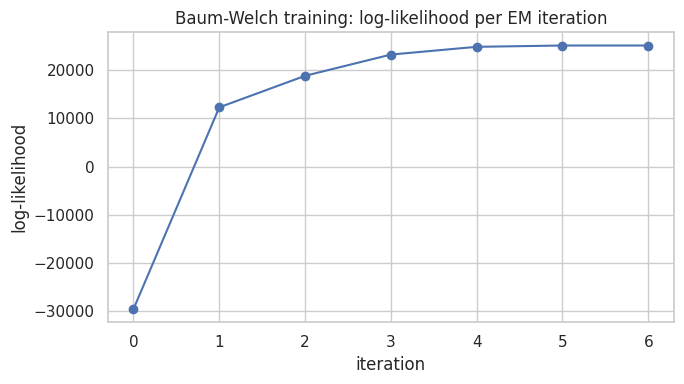

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(model.monitor_.history, marker="o")
plt.title("Baum-Welch training: log-likelihood per EM iteration")
plt.xlabel("iteration")
plt.ylabel("log-likelihood")
plt.tight_layout()
plt.show()


The curve rises gradually then flattens indicating that the Hidden Markov Model was trained using the Baum-Welch EM algorithm and the sequence was inferred using the Viterbi algorithm which separates the classes.


## 7. Mapping hidden states to activity labels



In [17]:
state_to_label = map_states_to_labels(model, X_train, train_lengths, train_df)

print("Hidden state -> activity label mapping:")
for state, label in sorted(state_to_label.items()):
    print(f"  state {state} -> {label}")

Hidden state -> activity label mapping:
  state 0 -> jumping
  state 1 -> standing
  state 2 -> walking
  state 3 -> still


Every hidden state maps to a different activity, with no two states collapsing onto the same label.

## 8. Visualize the learned transition matrix



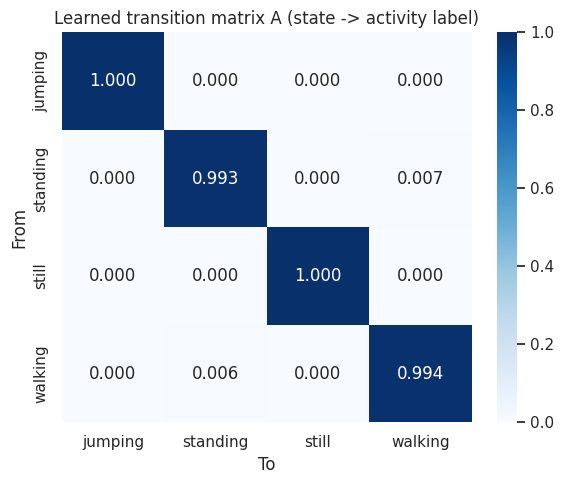

In [27]:
trans_df = pd.DataFrame(
    model.transmat_,
    index=[state_to_label[i] for i in range(4)],
    columns=[state_to_label[i] for i in range(4)],
)
# average duplicate-labelled rows/cols if any state collapsed onto the same label
trans_df = trans_df.groupby(trans_df.index).mean().T.groupby(level=0).mean().T

plt.figure(figsize=(6, 5))
sns.heatmap(trans_df, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1)
plt.title("Learned transition matrix A (state -> activity label)")
plt.ylabel("From")
plt.xlabel("To")
plt.tight_layout()
plt.show()


The transition matrix is strongly diagonal because each training is individual; there is no mixing therefore Baum-Welch never observes a real activity transitioning to another. This happened because I recorded each activity individually. If I were to record sequentially by walking, then jumping, then standing, and still, Baulm-Welch would have observed an activity transitioning to another.


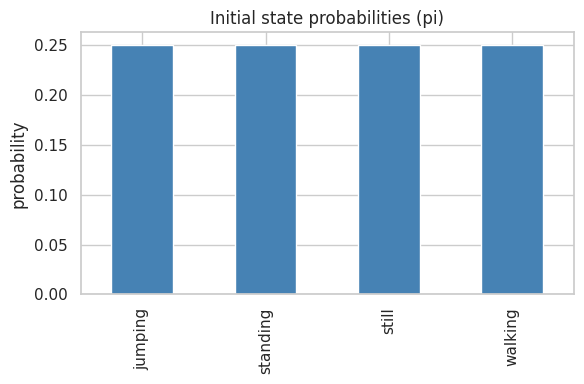

In [28]:
plt.figure(figsize=(6, 4))
pi_series = pd.Series(model.startprob_, index=[state_to_label[i] for i in range(4)])
pi_series.groupby(level=0).sum().plot(kind="bar", color="steelblue")
plt.title("Initial state probabilities (pi)")
plt.ylabel("probability")
plt.tight_layout()
plt.show()


The initial state probabilities of all 4 states are 0.25. This is because the training set is balanced therefore the Baum-Welch algorithm found no strong evidence that one hidden state should be the starting state of another.


## 9. Visualize emission probabilities




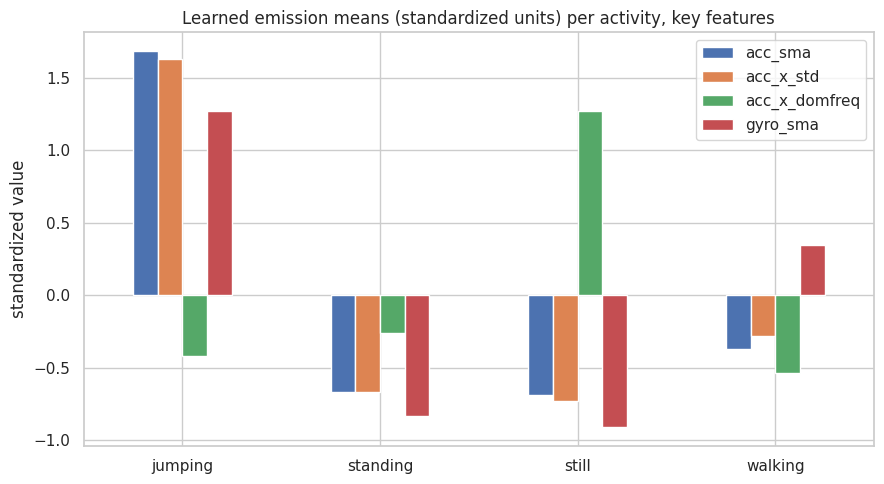

,acc_sma,acc_x_std,acc_x_domfreq,gyro_sma
jumping,1.684408,1.628474,-0.418282,1.273963
standing,-0.665560,-0.667778,-0.263233,-0.833141
still,-0.689146,-0.728222,1.269211,-0.908327
walking,-0.371114,-0.282311,-0.533656,0.348076


In [29]:
key_features = ["acc_sma", "acc_x_std", "acc_x_domfreq", "gyro_sma"]
key_idx = [feature_cols.index(f) for f in key_features]

means_df = pd.DataFrame(
    model.means_[:, key_idx],
    index=[state_to_label[i] for i in range(4)],
    columns=key_features,
)
means_df = means_df.groupby(level=0).mean()

means_df.plot(kind="bar", figsize=(9, 5))
plt.title("Learned emission means (standardized units) per activity, key features")
plt.ylabel("standardized value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
means_df


Jumping has the highest `acc_sma` and `acc_x_std` (high-energy, high-variance movement) while s:till has the lowest of both.

## 10. Decode the unseen test trials with Viterbi



In [30]:
cm, cm_df, results_table, test_pred_labels, test_true_labels = evaluate(
    model, X_test, test_lengths, test_df, state_to_label
)

test_df_result = test_df[["trial_id", "activity"]].copy()
test_df_result["predicted"] = test_pred_labels
test_df_result["correct"] = test_df_result["activity"] == test_df_result["predicted"]
test_df_result.head(10)

,trial_id,activity,predicted,correct
0,jumping_11,jumping,jumping,True
1,jumping_11,jumping,jumping,True
2,jumping_11,jumping,jumping,True
3,jumping_11,jumping,jumping,True
4,jumping_11,jumping,jumping,True
5,jumping_11,jumping,jumping,True
6,jumping_11,jumping,jumping,True
7,jumping_11,jumping,jumping,True
8,jumping_11,jumping,jumping,True
9,jumping_11,jumping,jumping,True


I recorded 13 trials for each activity. Trials 1-10 were used for training the model while trials 11-13 were used to test the performance of the model. Therefore, the dataset was split by a whole trial to prevent data leakage. This ensured overlapping windows from the same recording did not appear in both training and test sets. This resulted in a training set of 632 windows from 40 trials and a test set of 200 windows from 12 unseen trials. This shows the ability of the Hidden Markov Model to generalize new recordings.


### Decoded sequence plots (predicted vs. ground truth)



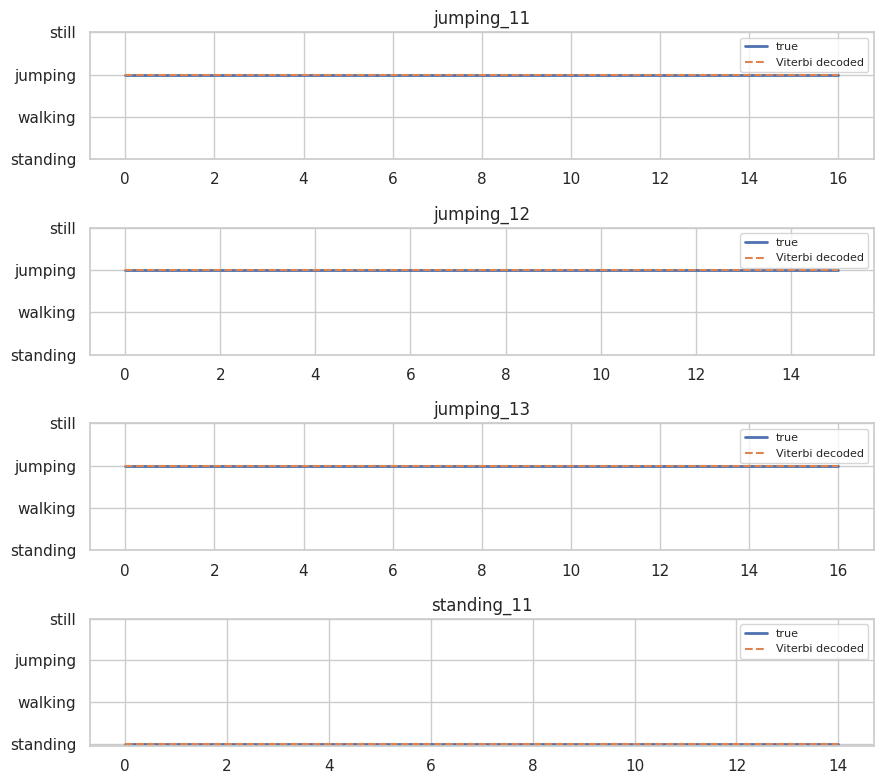

In [31]:
sample_test_trials = test_df["trial_id"].unique()[:4]
activity_to_idx = {a: i for i, a in enumerate(ACTIVITIES)}

fig, axes = plt.subplots(len(sample_test_trials), 1, figsize=(9, 8), sharex=False)
for ax, tid in zip(axes, sample_test_trials):
    sub = test_df_result[test_df_result["trial_id"] == tid].reset_index(drop=True)
    true_y = sub["activity"].map(activity_to_idx)
    pred_y = sub["predicted"].map(activity_to_idx)
    ax.step(range(len(sub)), true_y, where="post", label="true", linewidth=2)
    ax.step(range(len(sub)), pred_y, where="post", label="Viterbi decoded", linestyle="--")
    ax.set_yticks(range(4))
    ax.set_yticklabels(ACTIVITIES)
    ax.set_title(tid)
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


The predictions are stable from one window to the next meaning that the HMM model uses temporal continuity to produce smooth predictions and reduce errors.


## 11. Evaluation: confusion matrix, sensitivity, specificity, accuracy



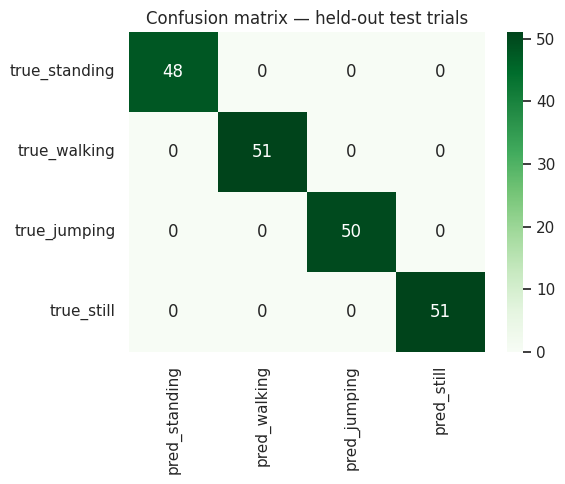

,pred_standing,pred_walking,pred_jumping,pred_still
true_standing,48,0,0,0
true_walking,0,51,0,0
true_jumping,0,0,50,0
true_still,0,0,0,51


In [32]:

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion matrix — held-out test trials")
plt.tight_layout()
plt.show()
cm_df

 There was no misclassification between the 4 activities resulting in a perfectly diagonal confusion matrix.

In [33]:
results_table

,Activity,Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,standing,48,1.0,1.0,1.0
1,walking,51,1.0,1.0,1.0
2,jumping,50,1.0,1.0,1.0
3,still,51,1.0,1.0,1.0


:The sensitivity and specificity has an overall accuracy of 1.0 across every class. This means that the Hidden Markov Model successfully distinguished the 4 activities.


## 12. Robustness check: does this hold up with a different held-out split?




Despite the test split achieving perfect classification, I conducted 4 different trial combinations to evaluate the robustness of the model.


In [34]:
def run_split(held_out_trial_nums):
    Xtr, Xte, ltr, lte, tr, te = split_by_trial(feat_df, feature_cols, held_out_trial_nums)
    m = fit_hmm(Xtr, ltr)
    state_to_label = map_states_to_labels(m, Xtr, ltr, tr)

    s_test = m.predict(Xte, lengths=lte)
    pred = np.array([state_to_label.get(s, "unmapped") for s in s_test])
    true = te["activity"].values
    acc = (pred == true).mean()
    return acc

held_out_splits = [(1, 2, 3), (4, 5, 6), (7, 8, 9), (11, 12, 13)]
robustness = pd.DataFrame({
    "held_out_trials": [str(h) for h in held_out_splits],
    "test_accuracy": [round(run_split(h), 3) for h in held_out_splits],
})
robustness

,held_out_trials,test_accuracy
0,"(1, 2, 3)",1.000
1,"(4, 5, 6)",0.775
2,"(7, 8, 9)",0.759
3,"(11, 12, 13)",1.000


The results above show that accuracy varied between 0.759 to 1.000 depending on the trials withheld for testing. (1,2,3) and (11,12,13) splits had perfect performance but (4,5,6) and (7,8,9) splits achieved accuracies of 0.775 and 0.759 respectively. This means that the model performs well overall, but the performance depends on the characteristics of unseen trials.


## 13. Analysis and reflection

According to the results, still was the easiest activity for the Hidden Markov Model to recognise. This is because it produced a stable accelerometer and gyroscope signals because of minimal activity compared to walking, jumping, and standing which were more difficult to distinguish the evaluation splits. Walking, jumping, and standing cause overlap in some feature values due to the body movements increasing the chances of confusion.

Moreover, the transition matrix was almost perfectly diagonal because of the isolated recordings of single activity trials. This is not realistic in the real world because in fitness monitoring applications, users frequently change between activities such as jumping, standing, and walking, and continuous multi-activity recordings would be needed to capture those changes.

In addition, the 100HZ I used for this was efficient for the gait and jump cycles. The real noise observed was the window-boundary effects at the beginning and end of activity recordings and not the sampling rate itself.  

In future, I could enhance the robustness of the activity recognition system by using continuous multi-activity recordings which would allow the HMM to learn transitions and improve temporal modelling. I would also incorporate orientation-independent magnitude-based features to reduce sensitivity to smartphone placement. Finally, I would also increase the number of trials per activity in order to improve parameter estimation.

